# Breast Cancer Wisconsin Diagnostic Model

**Breast cancer** remains one of the most common cancers affecting women worldwide, and early, accurate diagnosis is critical to improving treatment outcomes. This project uses the Wisconsin Breast Cancer diagnostic dataset.

The following models will include both parametric (e.g. SVM) and non-parametric (e.g. KNN) and linear (e.g. Logistic Regression) and nonlinear modles (e.g. Random Forest Classifier).

The folloing analysis runs the following **models**:

1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Support Vector Machine (SVM)
4. Decision Tree
5. Random Forest
6. Ensemble learning (Voting, Bagging, Boosting, Stacking)


Note: We set **Malignant = 1** and **Benign = 0**.

In [1]:
# Import Neo4j
!pip install neo4j

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 4.6 MB/s eta 0:00:00


In [17]:
# Import libraries and set up connection using Colab Secrets
from neo4j import GraphDatabase
from google.colab import userdata
import pandas as pd

URI = "neo4j+s://30b3e48b.databases.neo4j.io"
AUTH = ("30b3e48b", "GG_G03OF3CcPFO3H3D_Q5nOkCvyJbZYB3uhVgcs-PVw")

driver = GraphDatabase.driver(URI, auth=AUTH)

def run_query(query):
    with driver.session() as session:
        result = session.run(query)
        return [record.data() for record in result]

In [18]:
# Test the connection
print(run_query("MATCH (t:TumorDiagnosis) RETURN count(t) AS total"))
# Expected output: [{'total': 569}]

[{'total': 569}]


In [19]:
# Extract all data into a pandas DataFrame
query = """
MATCH (t:TumorDiagnosis)
RETURN t.id AS id,
       t.diagnosis AS diagnosis,
       t.radiusMean AS radiusMean,
       t.textureMean AS textureMean,
       t.perimeterMean AS perimeterMean,
       t.areaMean AS areaMean,
       t.smoothnessMean AS smoothnessMean,
       t.compactnessMean AS compactnessMean,
       t.concavityMean AS concavityMean,
       t.concavePointsMean AS concavePointsMean,
       t.symmetryMean AS symmetryMean,
       t.fractalDimensionMean AS fractalDimensionMean,
       t.radiusSe AS radiusSe,
       t.textureSe AS textureSe,
       t.perimeterSe AS perimeterSe,
       t.areaSe AS areaSe,
       t.smoothnessSe AS smoothnessSe,
       t.compactnessSe AS compactnessSe,
       t.concavitySe AS concavitySe,
       t.concavePointsSe AS concavePointsSe,
       t.symmetrySe AS symmetrySe,
       t.fractalDimensionSe AS fractalDimensionSe,
       t.radiusWorst AS radiusWorst,
       t.textureWorst AS textureWorst,
       t.perimeterWorst AS perimeterWorst,
       t.areaWorst AS areaWorst,
       t.smoothnessWorst AS smoothnessWorst,
       t.compactnessWorst AS compactnessWorst,
       t.concavityWorst AS concavityWorst,
       t.concavePointsWorst AS concavePointsWorst,
       t.symmetryWorst AS symmetryWorst,
       t.fractalDimensionWorst AS fractalDimensionWorst
"""

data = run_query(query)
df = pd.DataFrame(data)
print(df.shape)
df.head()

(569, 32)


,id,diagnosis,radiusMean,textureMean,perimeterMean,areaMean,smoothnessMean,compactnessMean,concavityMean,concavePointsMean,...,radiusWorst,textureWorst,perimeterWorst,areaWorst,smoothnessWorst,compactnessWorst,concavityWorst,concavePointsWorst,symmetryWorst,fractalDimensionWorst
0,8670,M,15.46,19.48,101.70,748.9,0.10920,0.12230,0.14660,0.08087,...,19.26,26.00,124.90,1156.0,0.15460,0.2394,0.3791,0.15140,0.2837,0.08019
1,8913,B,12.89,13.12,81.89,515.9,0.06955,0.03729,0.02260,0.01171,...,13.62,15.54,87.40,577.0,0.09616,0.1147,0.1186,0.05366,0.2309,0.06915
2,8915,B,14.96,19.10,97.03,687.3,0.08992,0.09823,0.05940,0.04819,...,16.25,26.19,109.10,809.8,0.13130,0.3030,0.1804,0.14890,0.2962,0.08472
3,9047,B,12.94,16.17,83.18,507.6,0.09879,0.08836,0.03296,0.02390,...,13.86,23.02,89.69,580.9,0.11720,0.1958,0.1810,0.08388,0.3297,0.07834
4,85715,M,13.17,18.66,85.98,534.6,0.11580,0.12310,0.12260,0.07340,...,15.67,27.95,102.80,759.4,0.17860,0.4166,0.5006,0.20880,0.3900,0.11790


In [21]:
# Imports Data Libraries
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    VotingClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")


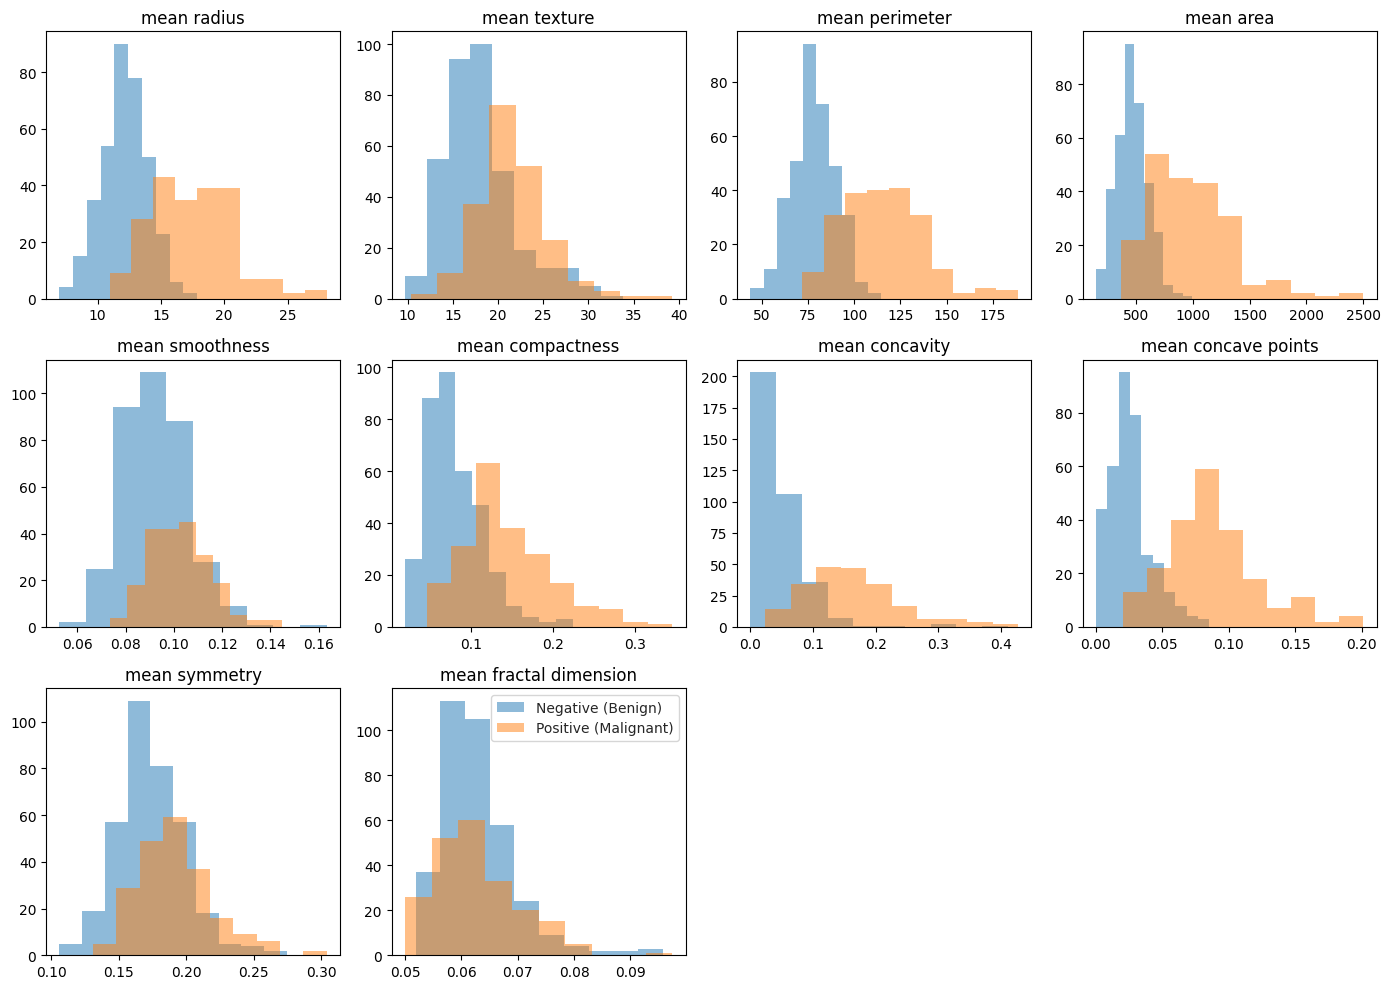

In [22]:
# Exploratory Data Analysis (EDA)- Tumor Characteristics Visualizations (Features 1–10)

import matplotlib.pyplot as plt
import seaborn as sns

bcdf = X.copy()

# malignant = 1 (positive), benign = 0 (negative)
bcdf_y = bcdf[y == 1]  # Positive (Malignant)
bcdf_n = bcdf[y == 0]  # Negative (Benign)

fig = plt.figure(figsize=(14, 10))

for i, b in enumerate(list(bcdf.columns[0:10]), start=1):
    ax = fig.add_subplot(3, 4, i)
    ax.hist(bcdf_n[b], label='Negative (Benign)', stacked=True, alpha=0.5)
    ax.hist(bcdf_y[b], label='Positive (Malignant)', stacked=True, alpha=0.5)
    ax.set_title(b)

sns.set_style("whitegrid")
plt.tight_layout()
plt.legend()
plt.show()


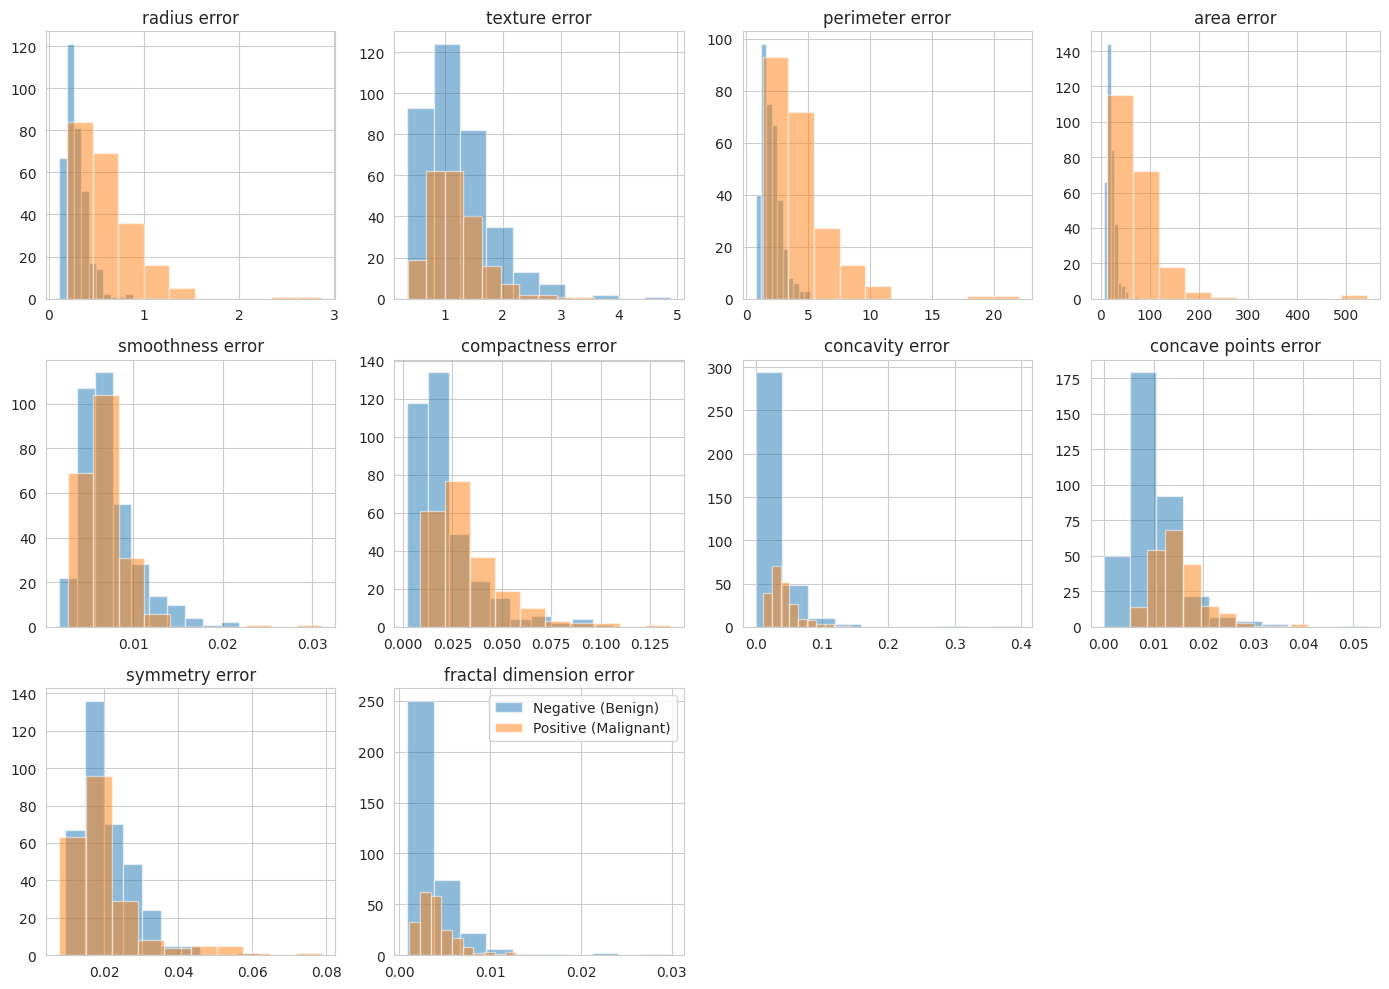

In [23]:
# Exploratory Data Analysis (EDA), Tumor Characteristics (Features 10–19)

import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(14, 10))

for i, b in enumerate(list(bcdf.columns[10:20]), start=1):
    ax = fig.add_subplot(3, 4, i)
    ax.hist(bcdf_n[b], label='Negative (Benign)', stacked=True, alpha=0.5)
    ax.hist(bcdf_y[b], label='Positive (Malignant)', stacked=True, alpha=0.5)
    ax.set_title(b)

sns.set_style("whitegrid")
plt.tight_layout()
plt.legend()
plt.show()


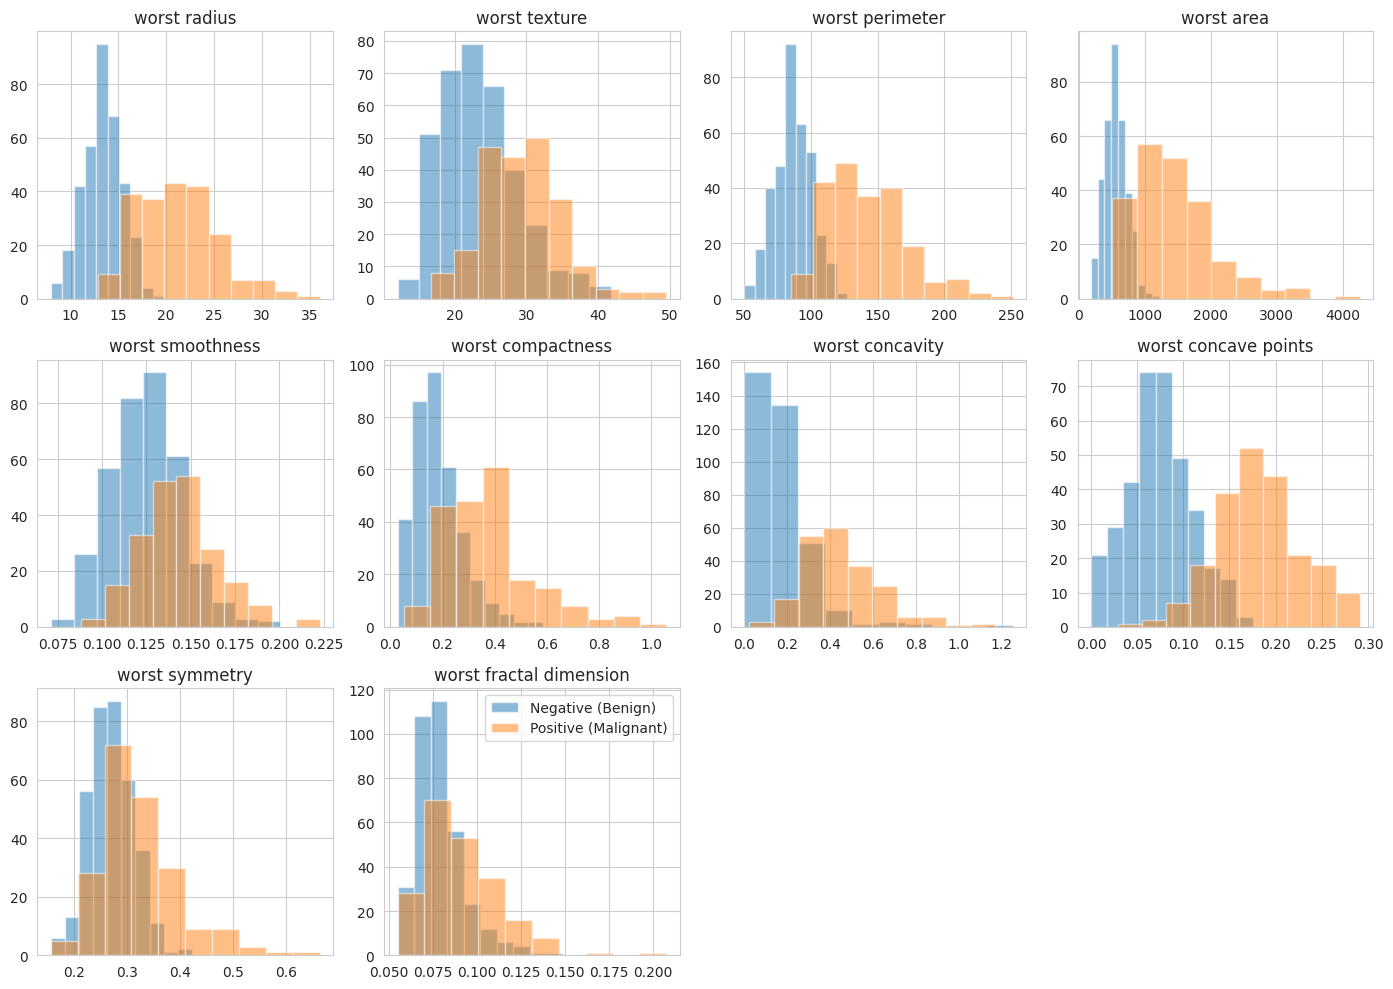

In [24]:
# Exploratory Data Analysis (EDA), Tumor Characteristics (Features 20–end)

import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(14, 10))

for i, b in enumerate(list(bcdf.columns[20:]), start=1):
    ax = fig.add_subplot(3, 4, i)
    ax.hist(bcdf_n[b], label='Negative (Benign)', stacked=True, alpha=0.5)
    ax.hist(bcdf_y[b], label='Positive (Malignant)', stacked=True, alpha=0.5)
    ax.set_title(b)

sns.set_style("whitegrid")
plt.tight_layout()
plt.legend()
plt.show()


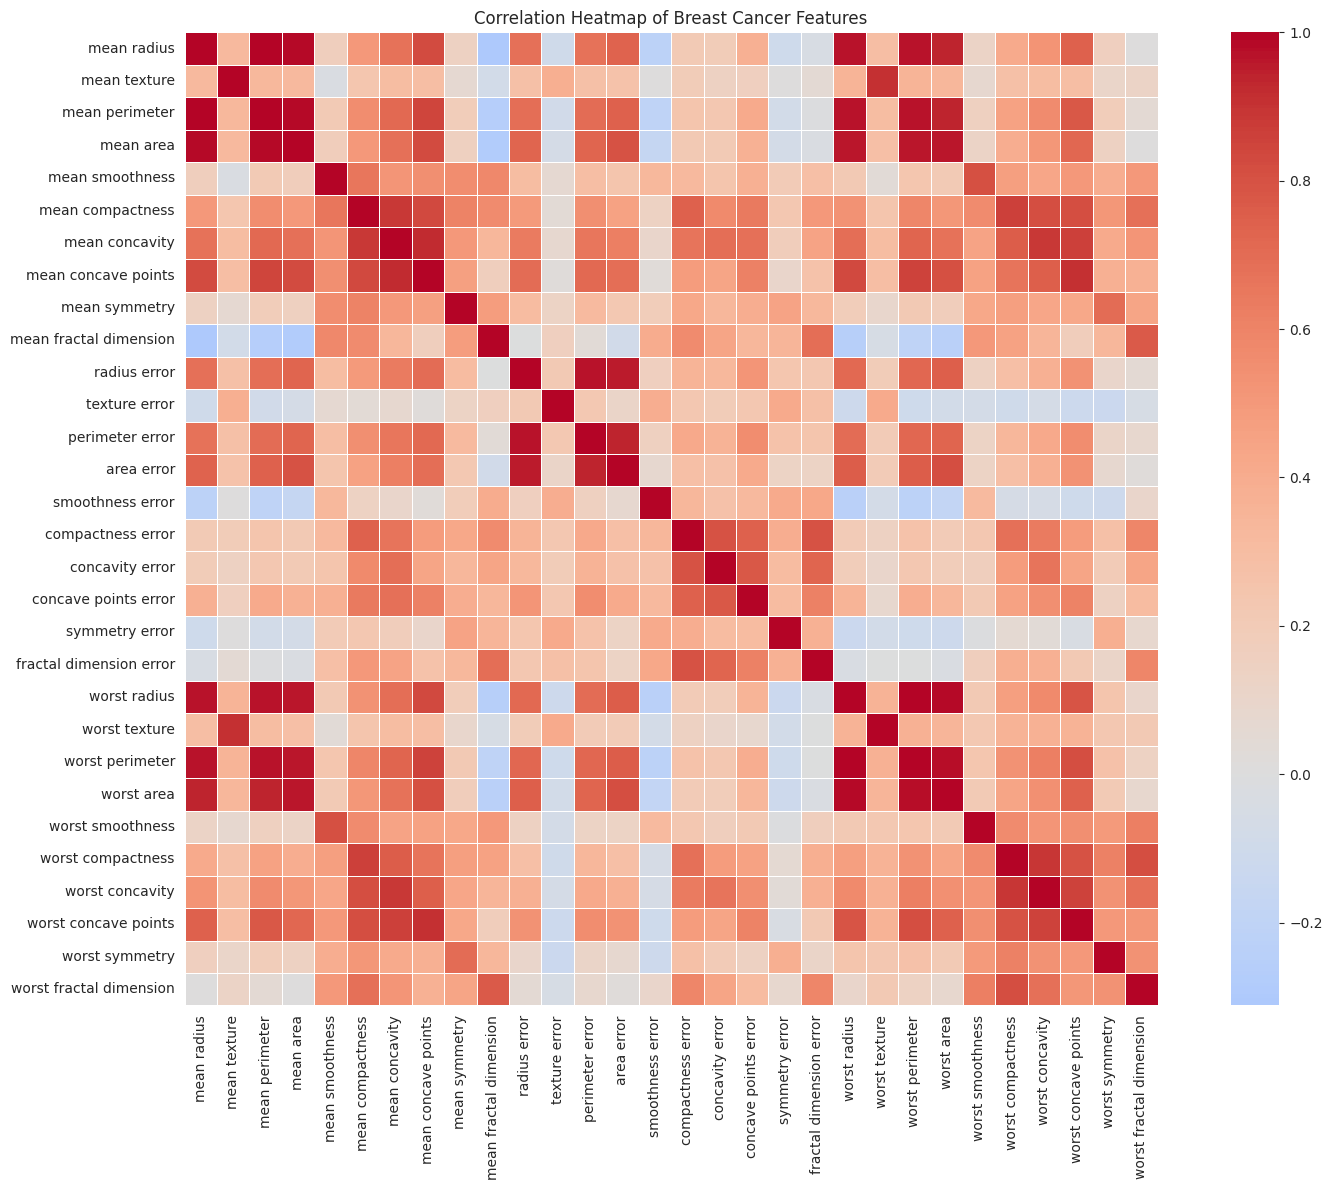

In [25]:
# Exploratory Data Analysis (EDA), Feature Correlation Heatmap

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 12))
sns.heatmap(
    bcdf.corr(),
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

sns.set_style("whitegrid")
plt.title("Correlation Heatmap of Breast Cancer Features")
plt.tight_layout()
plt.show()


## PCA Analaysis (Features Importance)

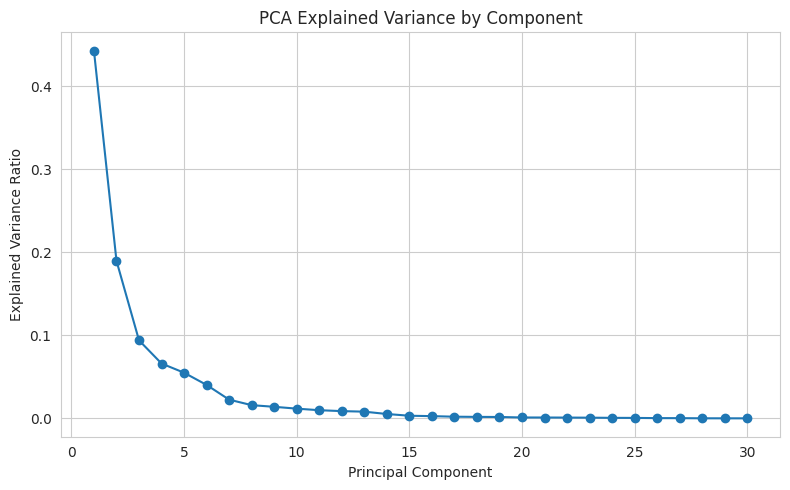

<Axes: xlabel='PC1', ylabel='PC2'>

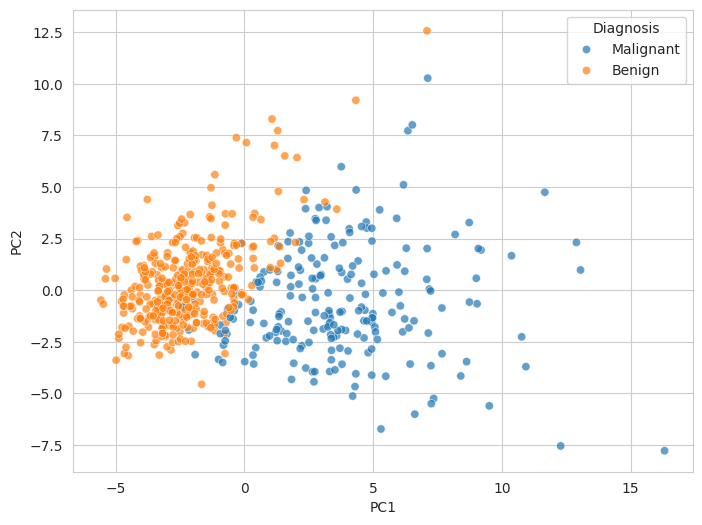

In [26]:
# Exploratory Data Analysis (EDA)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1) Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2) PCA for explained variance
pca = PCA()
X_pca_full = pca.fit_transform(X_scaled)

# Explained variance plot
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker='o'
)
plt.title("PCA Explained Variance by Component")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.grid(True)
plt.tight_layout()
plt.show()

# 3) PCA 2D projection
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca_2,
    columns=["PC1", "PC2"]
)

pca_df["Diagnosis"] = y.map({0: "Benign", 1: "Malignant"})

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Diagnosis",
    alpha=0.7
)


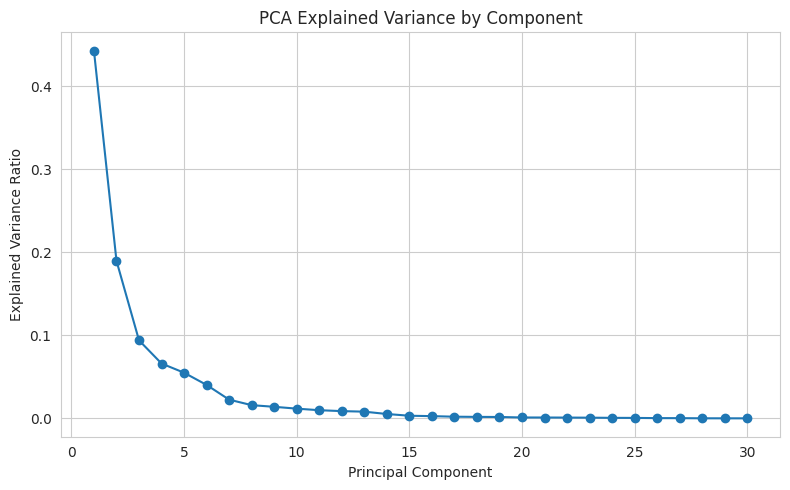

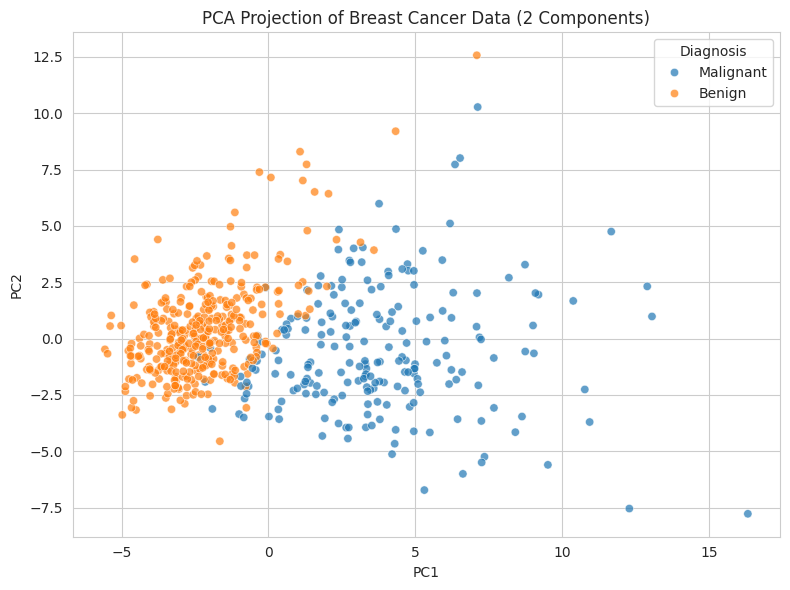


Top 10 features contributing to PC1 (by |weight|):
mean concave points     0.260854
mean concavity          0.258400
worst concave points    0.250886
mean compactness        0.239285
worst perimeter         0.236640
worst concavity         0.228768
worst radius            0.227997
mean perimeter          0.227537
worst area              0.224871
mean area               0.220995
Name: PC1, dtype: float64

Top 10 features contributing to PC2 (by |weight|):
mean fractal dimension     0.366575
fractal dimension error    0.280092
worst fractal dimension    0.275339
mean radius                0.233857
compactness error          0.232716
mean area                  0.231077
worst radius               0.219866
worst area                 0.219352
mean perimeter             0.215181
smoothness error           0.204430
Name: PC2, dtype: float64


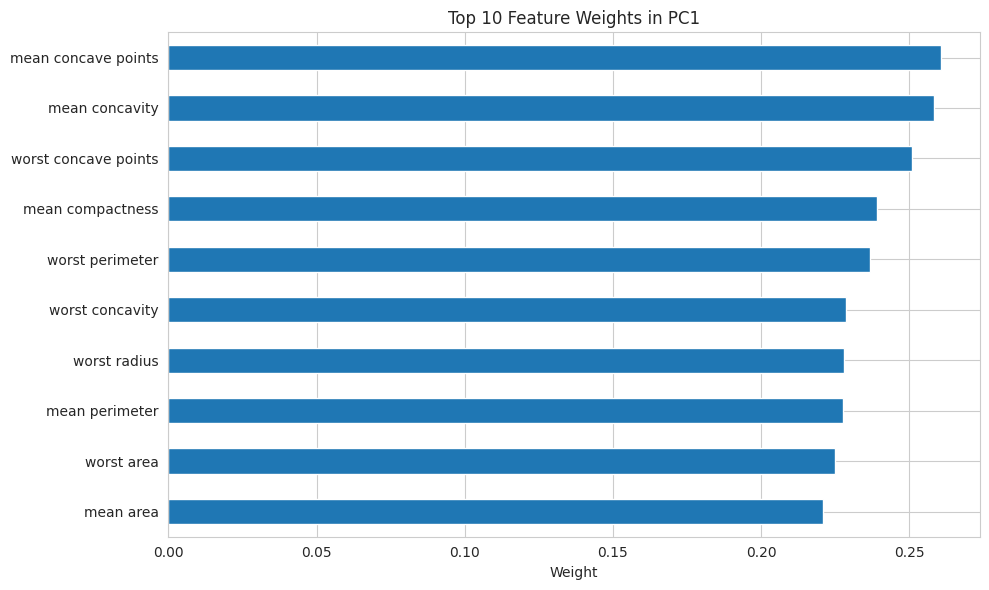

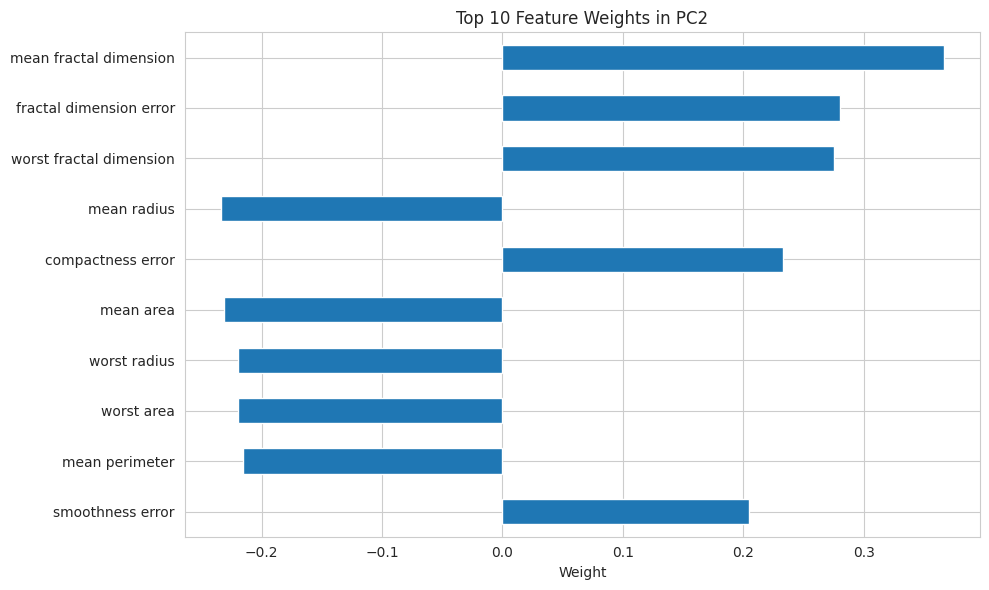

In [27]:
# EDA: PCA (Scaling + Variance + 2D Plot + Feature Weights/Loadings)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1) Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2) Fit PCA (all components) for explained variance + loadings
pca = PCA()
X_pca_full = pca.fit_transform(X_scaled)

# Explained variance plot
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker='o'
)
plt.title("PCA Explained Variance by Component")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.grid(True)
plt.tight_layout()
plt.show()

# 3) PCA 2D projection
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca_2, columns=["PC1", "PC2"])
pca_df["Diagnosis"] = y.map({0: "Benign", 1: "Malignant"})

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Diagnosis",
    alpha=0.7
)
plt.title("PCA Projection of Breast Cancer Data (2 Components)")
sns.set_style("whitegrid")
plt.tight_layout()
plt.show()

# 4) Feature weights (loadings) for each principal component
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.components_.shape[0])],
    index=X.columns
)

# Top 10 contributing features for PC1 and PC2 (by absolute weight)
top_pc1 = loadings["PC1"].abs().sort_values(ascending=False).head(10)
top_pc2 = loadings["PC2"].abs().sort_values(ascending=False).head(10)

print("\nTop 10 features contributing to PC1 (by |weight|):")
print(top_pc1)

print("\nTop 10 features contributing to PC2 (by |weight|):")
print(top_pc2)

# Visualize top loadings for PC1
plt.figure(figsize=(10, 6))
loadings["PC1"].sort_values(key=abs, ascending=False).head(10).plot(kind="barh")
plt.title("Top 10 Feature Weights in PC1")
plt.xlabel("Weight")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Visualize top loadings for PC2
plt.figure(figsize=(10, 6))
loadings["PC2"].sort_values(key=abs, ascending=False).head(10).plot(kind="barh")
plt.title("Top 10 Feature Weights in PC2")
plt.xlabel("Weight")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# Model Training


In [30]:
# Train/Test split (keep stratify to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (455, 30) (455,)
Test : (114, 30) (114,)


# Model Testing


In [29]:
# ML Models
TARGET_NAMES = ["benign (0)", "malignant (1)"]

def evaluate_and_store(model, model_name, X_test, y_test, results_dict):
    """Fits already-trained model predictions, prints standard evaluation, stores accuracy+precision."""
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)  # precision for malignant class

    print(f"\{model_name}")
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4), "(positive class = malignant)")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=TARGET_NAMES, zero_division=0))

    results_dict[model_name] = {"Accuracy": acc, "Precision": prec}
    return acc, prec


## 1) Logistic Regression

In [31]:
results = {}

lr_model = LogisticRegression(max_iter=5000, random_state=42)
lr_model.fit(X_train, y_train)

evaluate_and_store(lr_model, "Logistic Regression", X_test, y_test, results)


\Logistic Regression
Accuracy : 0.9386
Precision: 0.973 (positive class = malignant)

Confusion Matrix:
[[71  1]
 [ 6 36]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.92      0.99      0.95        72
malignant (1)       0.97      0.86      0.91        42

     accuracy                           0.94       114
    macro avg       0.95      0.92      0.93       114
 weighted avg       0.94      0.94      0.94       114



(0.9385964912280702, 0.972972972972973)

## 2) K-Nearest Neighbors (KNN)

In [32]:
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=10))
])
knn_model.fit(X_train, y_train)

evaluate_and_store(knn_model, "KNN (k=7)", X_test, y_test, results)


\KNN (k=7)
Accuracy : 0.9474
Precision: 0.9737 (positive class = malignant)

Confusion Matrix:
[[71  1]
 [ 5 37]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.93      0.99      0.96        72
malignant (1)       0.97      0.88      0.93        42

     accuracy                           0.95       114
    macro avg       0.95      0.93      0.94       114
 weighted avg       0.95      0.95      0.95       114



(0.9473684210526315, 0.9736842105263158)

## 3) Support Vector Machine (SVM)

In [33]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42))
])
svm_model.fit(X_train, y_train)

evaluate_and_store(svm_model, "SVM (RBF)", X_test, y_test, results)


\SVM (RBF)
Accuracy : 0.9737
Precision: 1.0 (positive class = malignant)

Confusion Matrix:
[[72  0]
 [ 3 39]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.96      1.00      0.98        72
malignant (1)       1.00      0.93      0.96        42

     accuracy                           0.97       114
    macro avg       0.98      0.96      0.97       114
 weighted avg       0.97      0.97      0.97       114



(0.9736842105263158, 1.0)

## 4) Decision Tree

In [34]:
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

evaluate_and_store(dt_model, "Decision Tree (max_depth=5)", X_test, y_test, results)


\Decision Tree (max_depth=5)
Accuracy : 0.9211
Precision: 0.9459 (positive class = malignant)

Confusion Matrix:
[[70  2]
 [ 7 35]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.91      0.97      0.94        72
malignant (1)       0.95      0.83      0.89        42

     accuracy                           0.92       114
    macro avg       0.93      0.90      0.91       114
 weighted avg       0.92      0.92      0.92       114



(0.9210526315789473, 0.9459459459459459)

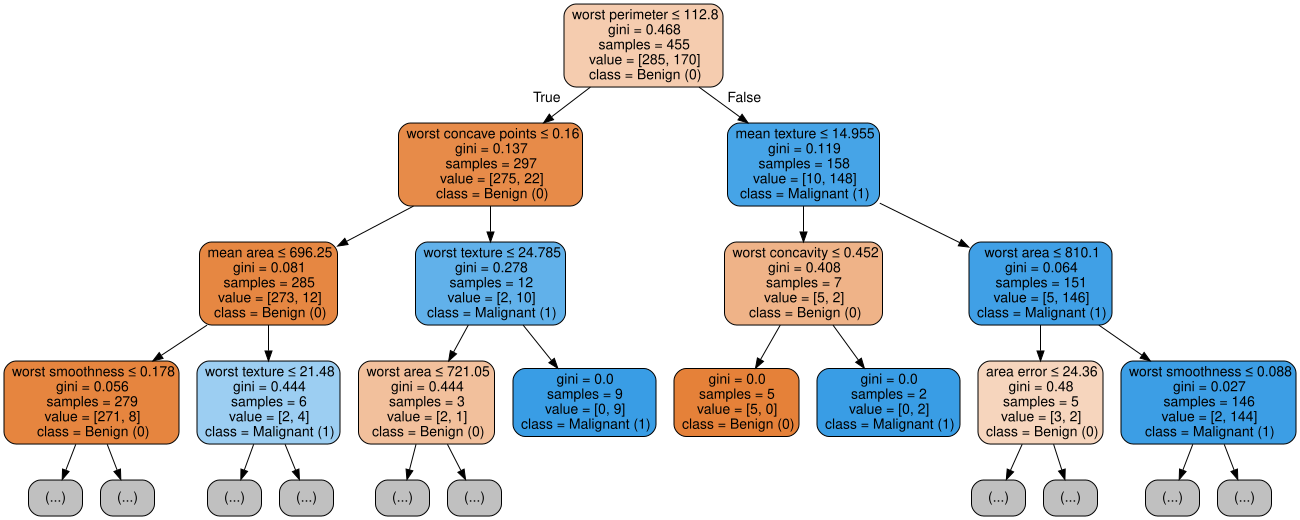

In [35]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    dt_model,
    out_file=None,
    feature_names=X.columns,
    class_names=["Benign (0)", "Malignant (1)"],
    filled=True,
    rounded=True,
    special_characters=True,
    max_depth=3
)

graph = graphviz.Source(dot_data)
graph


## 5) Random Forest

In [36]:
rf_model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

evaluate_and_store(rf_model, "Random Forest (n=300)", X_test, y_test, results)


\Random Forest (n=300)
Accuracy : 0.9737
Precision: 1.0 (positive class = malignant)

Confusion Matrix:
[[72  0]
 [ 3 39]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.96      1.00      0.98        72
malignant (1)       1.00      0.93      0.96        42

     accuracy                           0.97       114
    macro avg       0.98      0.96      0.97       114
 weighted avg       0.97      0.97      0.97       114



(0.9736842105263158, 1.0)

## Random Forest Fearure Importance

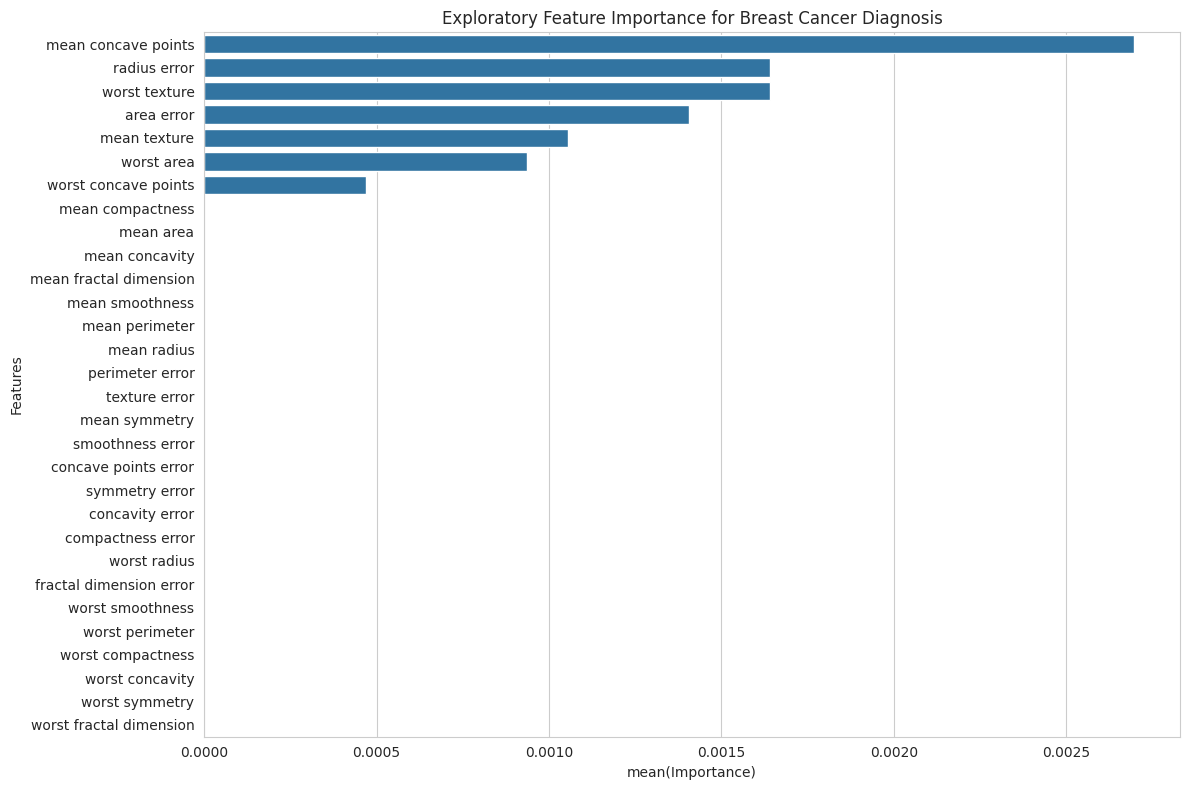

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Exploratory model
rf_eda = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_eda.fit(X, y)

perm = permutation_importance(
    rf_eda,
    X, y,
    n_repeats=15,
    random_state=42,
    n_jobs=-1
)

rfc_features = pd.DataFrame({
    "Features": X.columns,
    "Importance": perm.importances_mean
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(
    x="Importance",
    y="Features",
    data=rfc_features
)

plt.title("Exploratory Feature Importance for Breast Cancer Diagnosis")
plt.xlabel("mean(Importance)")
plt.ylabel("Features")
sns.set_style("whitegrid")
plt.tight_layout()
plt.show()


### Hyperparamters Optimization

In [38]:
# Hyperparameter Optimization
from sklearn.model_selection import GridSearchCV

# Logistic Regression
LR_params  = {"C":[0.001, 0.1, 1, 10, 100]}
KNN_params = {"n_neighbors":[1, 5, 10, 20], "p":[2], "metric":["minkowski"]}
SVM_params = {"C":[0.001, 0.1, 10, 100], "kernel":["rbf", "linear", "poly", "sigmoid"]}
DTC_params = {"criterion":["entropy", "gini"], "max_depth":[3, 5, 10, 50, None]}
RF_params  = {"n_estimators":[100, 300, 500], "max_depth":[None, 5, 10, 20]}


##GridSearch

In [39]:
from sklearn.model_selection import GridSearchCV

tuned_results = {}

# Logistic Regression
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=5000, random_state=42),
    LR_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
lr_grid.fit(X_train, y_train)
print("Best LR:", lr_grid.best_params_)
evaluate_and_store(lr_grid.best_estimator_, "Logistic Regression (Tuned)", X_test, y_test, tuned_results)

# KNN (scaled)
knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

knn_grid = GridSearchCV(
    knn_pipe,
    {"knn__" + k: v for k, v in KNN_params.items()},
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
knn_grid.fit(X_train, y_train)
print("Best KNN:", knn_grid.best_params_)
evaluate_and_store(knn_grid.best_estimator_, "KNN (Tuned)", X_test, y_test, tuned_results)

#SVM (scaled)
svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(probability=True, random_state=42))
])

svm_grid = GridSearchCV(
    svm_pipe,
    {"svm__" + k: v for k, v in SVM_params.items()},
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
svm_grid.fit(X_train, y_train)
print("Best SVM:", svm_grid.best_params_)
evaluate_and_store(svm_grid.best_estimator_, "SVM (Tuned)", X_test, y_test, tuned_results)

# Decision Tree
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    DTC_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
dt_grid.fit(X_train, y_train)
print("Best Decision Tree:", dt_grid.best_params_)
evaluate_and_store(dt_grid.best_estimator_, "Decision Tree (Tuned)", X_test, y_test, tuned_results)

# Random Forest
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    RF_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)
print("Best Random Forest:", rf_grid.best_params_)
evaluate_and_store(rf_grid.best_estimator_, "Random Forest (Tuned)", X_test, y_test, tuned_results)


Best LR: {'C': 10}
\Logistic Regression (Tuned)
Accuracy : 0.9298
Precision: 0.9474 (positive class = malignant)

Confusion Matrix:
[[70  2]
 [ 6 36]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.92      0.97      0.95        72
malignant (1)       0.95      0.86      0.90        42

     accuracy                           0.93       114
    macro avg       0.93      0.91      0.92       114
 weighted avg       0.93      0.93      0.93       114

Best KNN: {'knn__metric': 'minkowski', 'knn__n_neighbors': 5, 'knn__p': 2}
\KNN (Tuned)
Accuracy : 0.9561
Precision: 0.9744 (positive class = malignant)

Confusion Matrix:
[[71  1]
 [ 4 38]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.95      0.99      0.97        72
malignant (1)       0.97      0.90      0.94        42

     accuracy                           0.96       114
    macro avg       0.96      0.95      0.95       114


(0.9736842105263158, 1.0)

## Ensemble Learning (Voting, Bagging, Boosting, Stacking)
I applied four ensemble strategies and store their Accuracy + Precision.

In [40]:
# Voting (Hard + Soft)
base_lr = LogisticRegression(max_iter=5000, random_state=42)
base_knn = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=7))])
base_svm = Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42))])
base_rf  = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)

hard_voting = VotingClassifier(
    estimators=[("lr", base_lr), ("knn", base_knn), ("svm", base_svm), ("rf", base_rf)],
    voting="hard"
)
hard_voting.fit(X_train, y_train)
evaluate_and_store(hard_voting, "Ensemble - Voting (Hard)", X_test, y_test, results)

soft_voting = VotingClassifier(
    estimators=[("lr", base_lr), ("knn", base_knn), ("svm", base_svm), ("rf", base_rf)],
    voting="soft"
)
soft_voting.fit(X_train, y_train)
evaluate_and_store(soft_voting, "Ensemble - Voting (Soft)", X_test, y_test, results)


\Ensemble - Voting (Hard)
Accuracy : 0.9561
Precision: 1.0 (positive class = malignant)

Confusion Matrix:
[[72  0]
 [ 5 37]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.94      1.00      0.97        72
malignant (1)       1.00      0.88      0.94        42

     accuracy                           0.96       114
    macro avg       0.97      0.94      0.95       114
 weighted avg       0.96      0.96      0.96       114

\Ensemble - Voting (Soft)
Accuracy : 0.9561
Precision: 1.0 (positive class = malignant)

Confusion Matrix:
[[72  0]
 [ 5 37]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.94      1.00      0.97        72
malignant (1)       1.00      0.88      0.94        42

     accuracy                           0.96       114
    macro avg       0.97      0.94      0.95       114
 weighted avg       0.96      0.96      0.96       114



(0.956140350877193, 1.0)

In [ ]:
# Bagging (Decision Tree base)
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
bagging_model.fit(X_train, y_train)
evaluate_and_store(bagging_model, "Ensemble - Bagging (DT base)", X_test, y_test, results)


\Ensemble - Bagging (DT base)
Accuracy : 0.9737
Precision: 1.0 (positive class = malignant)

Confusion Matrix:
[[72  0]
 [ 3 39]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.96      1.00      0.98        72
malignant (1)       1.00      0.93      0.96        42

     accuracy                           0.97       114
    macro avg       0.98      0.96      0.97       114
 weighted avg       0.97      0.97      0.97       114



(0.9736842105263158, 1.0)

In [41]:
# Boosting (AdaBoost + Gradient Boosting)
adaboost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=300,
    learning_rate=0.5,
    random_state=42
)
adaboost_model.fit(X_train, y_train)
evaluate_and_store(adaboost_model, "Ensemble - AdaBoost", X_test, y_test, results)

gboost_model = GradientBoostingClassifier(random_state=42)
gboost_model.fit(X_train, y_train)
evaluate_and_store(gboost_model, "Ensemble - Gradient Boosting", X_test, y_test, results)


\Ensemble - AdaBoost
Accuracy : 0.9737
Precision: 1.0 (positive class = malignant)

Confusion Matrix:
[[72  0]
 [ 3 39]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.96      1.00      0.98        72
malignant (1)       1.00      0.93      0.96        42

     accuracy                           0.97       114
    macro avg       0.98      0.96      0.97       114
 weighted avg       0.97      0.97      0.97       114

\Ensemble - Gradient Boosting
Accuracy : 0.9649
Precision: 1.0 (positive class = malignant)

Confusion Matrix:
[[72  0]
 [ 4 38]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.95      1.00      0.97        72
malignant (1)       1.00      0.90      0.95        42

     accuracy                           0.96       114
    macro avg       0.97      0.95      0.96       114
 weighted avg       0.97      0.96      0.96       114



(0.9649122807017544, 1.0)

In [42]:
# Stacking
estimators = [
    ("lr", LogisticRegression(max_iter=5000, random_state=42)),
    ("knn", Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=7))])),
    ("svm", Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42))])),
    ("rf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
]
final_estimator = LogisticRegression(max_iter=5000, random_state=42)

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    stack_method="predict_proba",
    n_jobs=-1
)

stack_model.fit(X_train, y_train)
evaluate_and_store(stack_model, "Ensemble - Stacking", X_test, y_test, results)


\Ensemble - Stacking
Accuracy : 0.9649
Precision: 1.0 (positive class = malignant)

Confusion Matrix:
[[72  0]
 [ 4 38]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.95      1.00      0.97        72
malignant (1)       1.00      0.90      0.95        42

     accuracy                           0.96       114
    macro avg       0.97      0.95      0.96       114
 weighted avg       0.97      0.96      0.96       114



(0.9649122807017544, 1.0)

## Final Metrics Matrix (Accuracy + Precision)

In [ ]:
# Final Matrix, Model Evaluation, and Comparisons
all_results = {**results, **tuned_results}

metrics_matrix = (
    pd.DataFrame(all_results).T
      .sort_values(by="Accuracy", ascending=False)
)

metrics_matrix_rounded = metrics_matrix.copy()
metrics_matrix_rounded["Accuracy"] = metrics_matrix_rounded["Accuracy"].round(4)
metrics_matrix_rounded["Precision"] = metrics_matrix_rounded["Precision"].round(4)

metrics_matrix_rounded



,Accuracy,Precision
SVM (RBF),0.9737,1.0000
Random Forest (n=300),0.9737,1.0000
Ensemble - Bagging (DT base),0.9737,1.0000
Ensemble - AdaBoost,0.9737,1.0000
SVM (Tuned),0.9737,1.0000
Random Forest (Tuned),0.9737,1.0000
Ensemble - Gradient Boosting,0.9649,1.0000
Ensemble - Stacking,0.9649,1.0000
Ensemble - Voting (Hard),0.9561,1.0000
KNN (Tuned),0.9561,0.9744


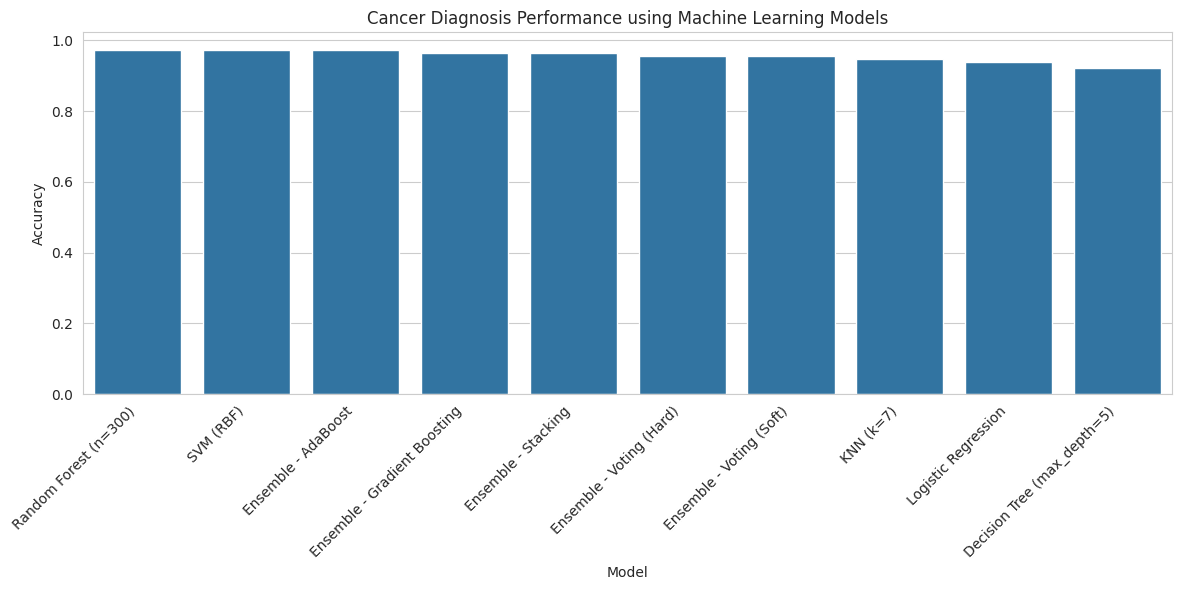

In [43]:
# Model Accuracy Comparison

import matplotlib.pyplot as plt
import seaborn as sns

# Convert results dictionary to DataFrame
accuracy_df = (
    pd.DataFrame(results).T
    .sort_values(by="Accuracy", ascending=False)
)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=accuracy_df.index,
    y=accuracy_df["Accuracy"]
)

plt.xticks(rotation=45, ha="right")
plt.title("Cancer Diagnosis Performance using Machine Learning Models")
plt.ylabel("Accuracy")
plt.xlabel("Model")
sns.set_style("whitegrid")
plt.tight_layout()
plt.show()
